In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../spectral-spatial-sst-model"))
from response_variable import seasonal_decompose

In [2]:
df = pd.read_csv("data/sst_timeseries.csv", index_col="time")
df

,a,b,c,d,e,f,g,h,i,j,k
time,,,,,,,,,,,
2005-01-01,6.884308,10.344086,15.349670,17.968353,18.657623,15.815063,19.246429,24.421936,21.211273,18.966125,17.160461
2005-02-01,6.681274,9.959991,14.603271,17.523621,18.557495,15.627563,19.179016,23.671997,20.970062,19.037231,17.199249
2005-03-01,7.018341,10.023224,14.463013,18.082336,18.884247,16.314758,19.366791,22.957733,21.325653,19.361664,18.230560
2005-04-01,7.370850,10.085175,14.243591,18.046448,18.622742,16.388672,19.623169,22.993164,21.536987,19.845001,19.271851
2005-05-01,9.399414,11.209930,15.292786,19.541412,19.634613,16.763916,19.932861,23.438293,24.601501,23.858337,21.390442
...,...,...,...,...,...,...,...,...,...,...,...
2025-04-01,7.305634,10.387573,14.350983,18.354797,18.392120,16.358673,19.724884,22.374298,22.763916,20.531311,19.772064
2025-05-01,8.352051,11.121887,15.201111,18.648407,18.383423,16.248138,19.541473,23.977417,24.852661,23.827515,21.586792
2025-06-01,10.523804,13.104248,16.147705,19.048218,18.909424,16.547699,19.717987,25.351074,28.238251,28.258392,25.778412


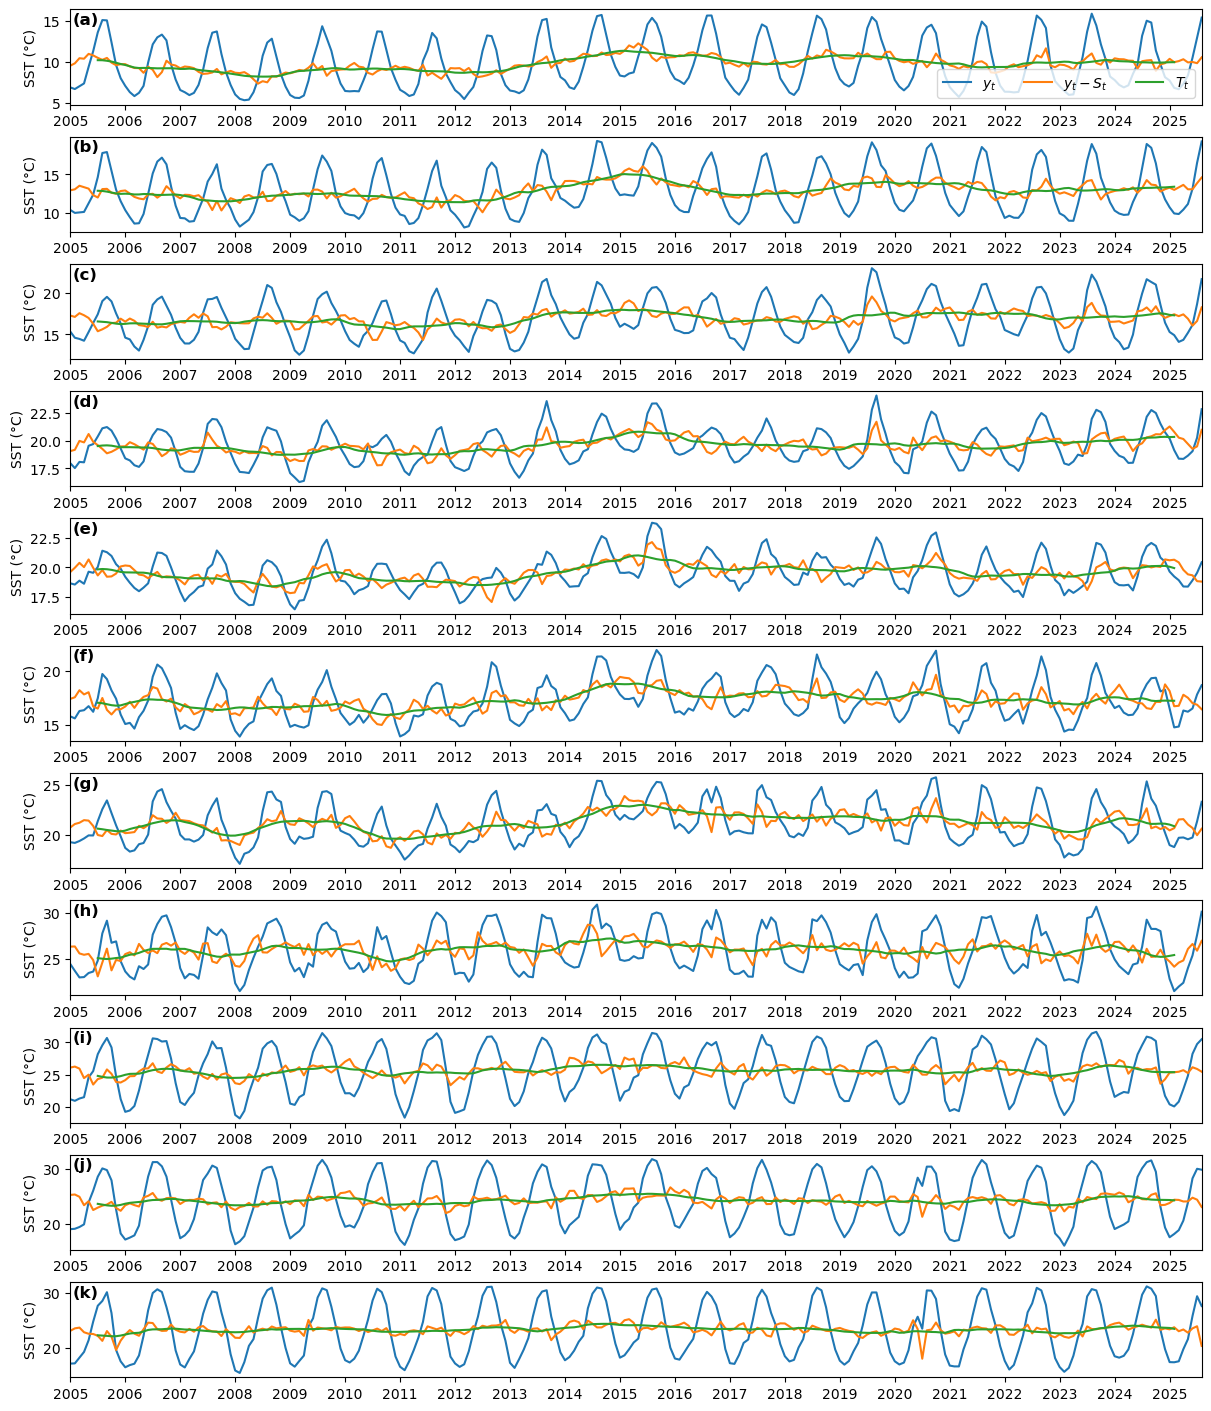

In [3]:
fig = plt.figure(figsize=(12, 14), constrained_layout=True) 
locations = list("abcdefghijk")

for k in range(len(locations)):
    ax = fig.add_subplot(len(locations), 1, k+1)
    
    serie = df[locations[k]];
    seasonal, trend = seasonal_decompose(serie)

    ax.plot(df.index, serie, label=r"$y_t$")
    ax.plot(df.index, serie - seasonal, label=r"$y_t - S_t$")
    ax.plot(df.index, trend, label=r"$T_t$")
    ax.set_xlim(df.index[0], df.index[-1])
    ax.set_xticks(df.index[::12])
    ax.set_xticklabels(np.arange(2005,2026), fontsize=10)
    ax.set_ylabel("SST (°C)")
    ax.text(0.0025,0.89, f"({locations[k]})", fontsize=12, fontweight='bold', color='black', ha='left', va='center', transform=ax.transAxes)

    if k == 0: ax.legend(ncol=3, loc="lower right")
plt.show()

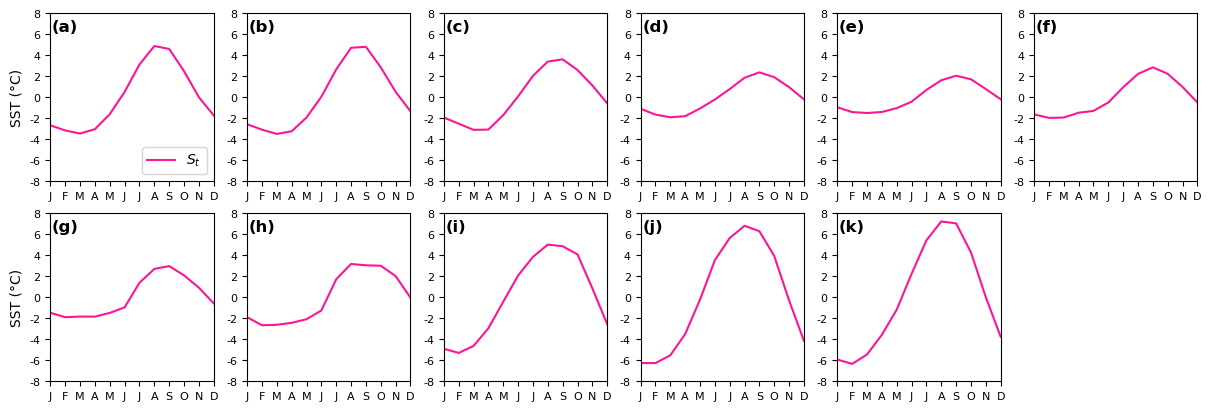

In [4]:
fig = plt.figure(figsize=(12, 4), constrained_layout=True) 
locations = list("abcdefghijk")

for k in range(len(locations)):
    ax = fig.add_subplot(2, int(len(locations)/2)+1, k+1)
    serie = df[locations[k]];

    seasonal, _ = seasonal_decompose(serie)
    
    ax.plot(np.arange(1,13), seasonal[:12], color="deeppink", label=r"$S_t$")
    ax.set_ylim(-8,8)
    ax.set_yticks(np.arange(-8,8+2,2))
    ax.set_yticklabels(np.arange(-8,8+2,2), fontsize=8)
    ax.set_xticks(np.arange(1,13))
    ax.set_xlim(1,12)
    ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"], fontsize=8)
    ax.text(0.01, 0.92, f"({locations[k]})", fontsize=12, fontweight='bold', color='black', ha='left', va='center', transform=ax.transAxes)

    if k == 0: ax.legend(loc="lower right")
    if k in [0,6]: ax.set_ylabel("SST (°C)")
plt.show()